# Q1. Interactive Regular Polygon

Write a function `ngon(n)` that generates the coordinates of a regular polygon with \( n \) sides.

The polygon should:
- be centered at the origin \((0,0)\)
- lie on the unit circle (radius = 1)

The function must return two lists (or arrays):
- \( x \): the \(x\)-coordinates of the vertices  
- \( y \): the \(y\)-coordinates of the vertices  

---

### Task

Use `ipywidgets.interact` to create a slider for \( n \) ranging from 3 to 20.

For each selected value of \( n \):

- Call the function `ngon(n)`
- Plot the polygon using `plt.plot`
- Close the polygon properly (connect the last vertex to the first)
- Use equal aspect ratio and add a title
- Use plt.axis('equal') to keep the x and y scales the same.

`Take help from Assignment-2`


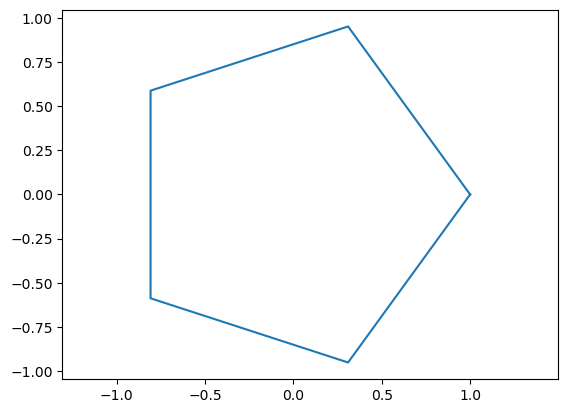

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def ngon(n):
    if n <= 2:
        raise ValueError("n must be greater than 2")
    
    theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
    x = np.cos(theta)
    y = np.sin(theta)

    x = np.append(x, x[0])
    y = np.append(y, y[0])
    plt.plot(x, y)
    plt.axis('equal')
    return x, y

x, y = ngon(5)

In [3]:
import ipywidgets as widgets

widgets.interact(lambda n: ngon(n), n=widgets.IntSlider(min=3, max=20));

interactive(children=(IntSlider(value=3, description='n', max=20, min=3), Output()), _dom_classes=('widget-int…

# Q2. Interactive Cobweb Plot for the Logistic Map

The logistic map is defined as

$$
x_{t+1} = f(x_t) = r x_t (1 - x_t),
$$

where $r$ is a parameter and $x_0$ is the initial value (starting point), with $0 < x_0 < 1$.

A **cobweb plot** is a graphical method to visualize how the sequence
$$
x_0, x_1, x_2, \dots
$$
evolves under repeated iteration of $f(x)$.

---

### Task

1. Define the function
$$
f(x) = r x (1-x).
$$

2. Use `ipywidgets.interact` to create interactive controls for:
   - $r$ ranging from 2.5 to 4.0
   - $x_0$ ranging from 0.01 to 0.99
   - number of iterations $N$ ranging from 10 to 100

3. For each chosen set of parameters, plot on the same figure:
   - the curve $y=f(x)$ for $x \in [0,1]$
   - the line $y=x$
   - the cobweb steps (vertical and horizontal lines)

4. Display the final iterate $x_N$ in the plot title.

5. Observe how the cobweb behavior changes for different values of $r$.


In [4]:
def logistic_function(x, r):
    return r * x * (1 - x)

def cobweb_plot(r, x0, n_iter):
    # Create x values for smooth curve
    x = np.linspace(0, 1, 400)
    y = logistic_function(x, r)

    # Plot logistic curve
    plt.plot(x, y)

    # Plot diagonal y = x
    plt.plot(x, x)

    # Initial point
    x_n = x0

    for _ in range(n_iter):
        # Vertical line: (x_n, x_n) → (x_n, f(x_n))
        y_n = logistic_function(x_n, r)
        plt.plot([x_n, x_n], [x_n, y_n])

        # Horizontal line: (x_n, y_n) → (y_n, y_n)
        plt.plot([x_n, y_n], [y_n, y_n])

        # Update
        x_n = y_n

    plt.title(f"Cobweb Plot (r={r}, final x_N={x_n:.4f})")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True)

widgets.interact(lambda r, x0, n_iter: cobweb_plot(r, x0, n_iter), r=widgets.FloatSlider(min=2.5, max=4.0), x0=widgets.FloatSlider(min=0.01, max=0.99), n_iter=widgets.IntSlider(min=10, max=100));

plt.show()

interactive(children=(FloatSlider(value=2.5, description='r', max=4.0, min=2.5), FloatSlider(value=0.01, descr…

# Q3. Interactive Comparison of Batsmen Using Boxplot and Violin Plot

In the folder "data", you can find given four text files:

- `dhoni.txt`
- `kohli.txt`
- `rohit.txt`
- `gambhir.txt`

Each file contains a list of runs scored by that batsman (one score per line).

---

### Task

1. Load the runs from all four files into separate NumPy arrays.

2. Use `ipywidgets.interact` to create an interactive control with:
   - a dropdown (or toggle) to choose the plot type: '"boxplot"' or '"violin"'

3. For the selected plot type, display a single figure that compares **all four batsmen** on the same plot:
   - x-axis: batsman names  
   - y-axis: runs scored  

4. In the output (below the plot), print for each batsman:
   - mean runs
   - median runs
   - standard deviation of runs

5. Based on the visual comparison, briefly comment on:
   - which batsman appears most consistent  
   - which batsman shows the highest variability  


In [7]:
dhoni_data = np.loadtxt('data/dhoni.txt')
kohli_data = np.loadtxt('data/kohli.txt')
rohit_data = np.loadtxt('data/rohit.txt')
gambhir_data = np.loadtxt('data/gambhir.txt')

def plot_type(type):
    if type == 'boxplot':
        plt.boxplot((dhoni_data, kohli_data, rohit_data, gambhir_data),
                     tick_labels=['dhoni', 'kohli', 'rohit', 'gambhir'],
                     showmeans=True, patch_artist=True)
        plt.show()
    elif type == 'violin':
        plt.violinplot((dhoni_data, kohli_data, rohit_data, gambhir_data),
                        showmeans=True, showmedians=True)
        plt.xticks([1, 2, 3, 4], ['dhoni', 'kohli', 'rohit', 'gambhir'])
        plt.show()
    else:
        print("Invalid type. Please choose 'boxplot' or 'violin'.")

widgets.interact(plot_type, type=widgets.RadioButtons(options=['boxplot', 'violin']));

dhoni_mean = np.mean(dhoni_data)
kohli_mean = np.mean(kohli_data)
rohit_mean = np.mean(rohit_data)
gambhir_mean = np.mean(gambhir_data)

dhoni_median = np.median(dhoni_data)
kohli_median = np.median(kohli_data)
rohit_median = np.median(rohit_data)
gambhir_median = np.median(gambhir_data)

dhoni_std = np.std(dhoni_data)
kohli_std = np.std(kohli_data)
rohit_std = np.std(rohit_data)
gambhir_std = np.std(gambhir_data)



interactive(children=(RadioButtons(description='type', options=('boxplot', 'violin'), value='boxplot'), Output…

In [8]:
print(f"Dhoni - Mean: {dhoni_mean}, Median: {dhoni_median}, Std Dev: {dhoni_std}")
print(f"Kohli - Mean: {kohli_mean}, Median: {kohli_median}, Std Dev: {kohli_std}")
print(f"Rohit - Mean: {rohit_mean}, Median: {rohit_median}, Std Dev: {rohit_std}")
print(f"Gambhir - Mean: {gambhir_mean}, Median: {gambhir_median}, Std Dev: {gambhir_std}")

Dhoni - Mean: 33.861111111111114, Median: 21.5, Std Dev: 35.19304127694831
Kohli - Mean: 48.9, Median: 36.5, Std Dev: 42.83521351926916
Rohit - Mean: 42.14339622641509, Median: 25.0, Std Dev: 44.85601917680808
Gambhir - Mean: 36.62937062937063, Median: 27.0, Std Dev: 35.17760697476486


In [9]:
print('Gambhir seems to be more consistent as the standard deviatio is the lowest')
print('Rohit has the highest variability as the standard deviation is the highest and the boxplot shows more outliers')

Gambhir seems to be more consistent as the standard deviatio is the lowest
Rohit has the highest variability as the standard deviation is the highest and the boxplot shows more outliers


# Q4. Interactive Batting Consistency Analysis

In the `data/` folder, each batsman’s runs are stored in separate text files:

- `dhoni.txt`
- `kohli.txt`
- `rohit.txt`
- `gambhir.txt`

Each file contains one run value per line.

Let $X$ denote the number of runs scored by a batsman in an innings.

---

## Task

###  Load Data and Define Probability Function

Select any one batsman from the `data/` folder and load the scores into a NumPy array.

Write a function that computes the probability:$P(X \geq t)$, where $t$ is a threshold score.

---

### Create Interactive Visualization

Use `ipywidgets.interact` to create a slider for $t$ ranging from 0 to 100.

For each selected value of $t$, display:

- The probability $P(X \geq t)$
- The number of innings where $X \geq t$

---

### Hint

You may use:

- `numpy` for calculations  
- Boolean indexing (e.g., `X >= t`)  
- `len()` to count values  
- `ipywidgets.interact` to create the slider

In [10]:
kohli_data = np.loadtxt('data/kohli.txt')
print(type(kohli_data))

def probaility_score(threshold):
    count_above_threshold = np.sum(kohli_data >= threshold)
    total_count = len(kohli_data)
    probability = count_above_threshold / total_count
    return probability, count_above_threshold

widgets.interact(lambda threshold: probaility_score(threshold), threshold=widgets.IntSlider(min=0, max=100));

<class 'numpy.ndarray'>


interactive(children=(IntSlider(value=0, description='threshold'), Output()), _dom_classes=('widget-interact',…

# Q5. Interactive Conditional Probability of Scoring a Half-Century

In the `data/` folder, each batsman’s runs are stored in separate text files:

- `dhoni.txt`
- `kohli.txt`
- `rohit.txt`
- `gambhir.txt`

Each file contains one run value per line.

Let $X$ denote the number of runs scored by a batsman in an innings.

We define the conditional probability:

$$
P(X \ge 50 \mid X \ge k)
$$

where $k$ is a threshold score.

---

### Task

1. Select any one batsman from the `data/` folder and load the scores into a NumPy array.

2. Write a function that computes:

$$
P(X \ge 50 \mid X \ge k)
$$

for a given value of $k$.

3. Use `ipywidgets.interact` to create a slider for $k$ ranging from 0 to 40.

4. For each value of $k$, display:
   - the computed conditional probability
   - the number of innings satisfying $X \ge k$


In [11]:
kohli_data = np.loadtxt('data/kohli.txt')
def conditional_probabilty(threshold):
    B = kohli_data >= threshold
    A = kohli_data >= 50

    count_B = np.sum(B)
    count_A_and_B = np.sum(A & B)

    p_conditional = count_A_and_B / count_B if count_B > 0 else 0
    print(f"P(X≥50 | X≥{threshold}) = {p_conditional:.4f}  (count = {count_B})")
    return p_conditional, count_B

widgets.interact(lambda threshold: conditional_probabilty(threshold), threshold=widgets.IntSlider(min=0, max=40));

interactive(children=(IntSlider(value=0, description='threshold', max=40), Output()), _dom_classes=('widget-in…

# Q6. Central Limit Theorem Exercise:
### In this exercise, you will illustrate the Central Limit Theorem (CLT) using a non-normal distribution from `scipy.stats`.

### Task: a) Define the Exponential distribution with scale parameter 2, i.e `X∼Exponential(scale=2)`. Its theoretical mean and variance are: $μ=2,σ^2=4$.

In [12]:
import scipy.stats as stats

exponential_distribution = stats.expon(scale=2)  # λ = 0.5

mean = exponential_distribution.mean()
variance = exponential_distribution.var()

print(f"Mean: {mean}, Variance: {variance}")

Mean: 2.0, Variance: 4.0


### Task: b) Simulate sample means for $𝑛=3$
Draw a random sample of size $𝑛=3$ from the exponential distribution and compute its sample mean (average). Repeat this experiment $10,000$ times (use `for` loop).  Plot the histogram of the average values. Compute the variance of average values.



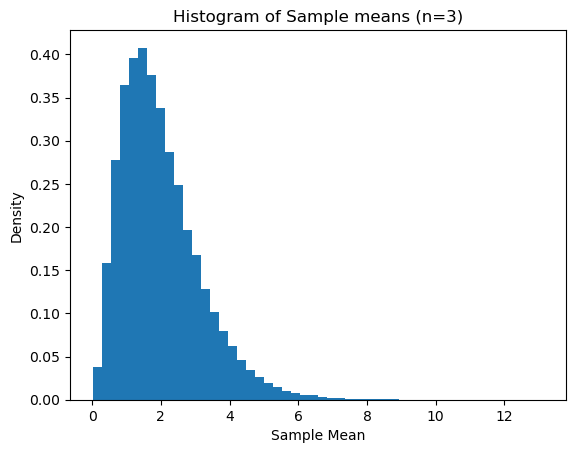

Variance of Sample Means: 1.3336


In [13]:
n = 3
experiments = 100000

sample_means = []
for _ in range(experiments):
    sample = exponential_distribution.rvs(size=n)
    sample_means.append(np.mean(sample))

sample_means = np.array(sample_means)
plt.hist(sample_means, bins=50, density=True);
plt.title('Histogram of Sample means (n=3)');
plt.xlabel('Sample Mean');
plt.ylabel('Density');
plt.show()

variance_sample_means = np.var(sample_means)
print(f"Variance of Sample Means: {variance_sample_means:.4f}")


### Task c) Repeat Task b) for several sample sizes
Repeat the simulation for the sample sizes for $n=3,5,10,15,50,100$

Each time:
- Generate 10,000 sample means
- Plot the histogram of the sample means,
- Superimpose the appropriate normal density $ \approx N( 2,\frac{4}{n}) $
  
Arrange the plots neatly so that you can observe how the histogram becomes more normal as `𝑛` increases.

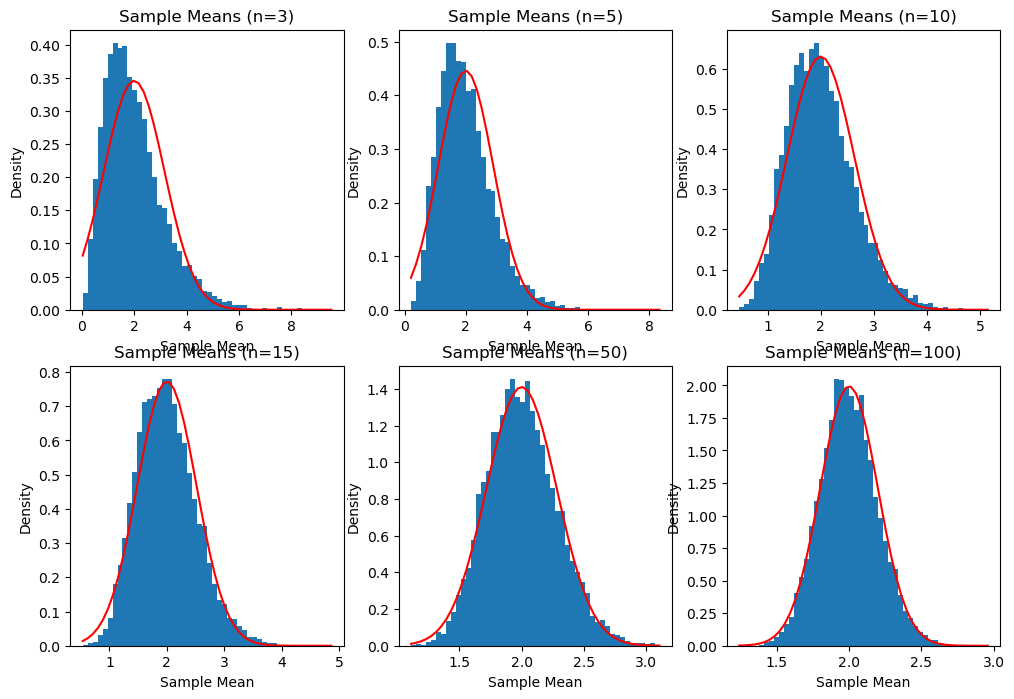

In [14]:
scale = 2
experiments = 10000
sample_space = [3, 5, 10, 15, 50, 100]

distribution = stats.expon(scale=scale)

plt.figure(figsize=(12, 8))

for i, n in enumerate(sample_space):
    sample_means = []
    for _ in range(experiments):
        sample = distribution.rvs(size=n)
        sample_means.append(np.mean(sample))
    
    sample_means = np.array(sample_means)
    plt.subplot(2, 3, i+1)
    plt.hist(sample_means, bins=50, density=True)

    mu = 2
    sigma = np.sqrt(4 / n)
    x = np.linspace(min(sample_means), max(sample_means))
    plt.plot(x, stats.norm.pdf(x, mu, sigma), color='red', label='Normal PDF')
    plt.title(f'Sample Means (n={n})')
    plt.xlabel('Sample Mean')
    plt.ylabel('Density')


## Task d) Compare empirical and theoretical variance
### Plot variance against `n`
- Compute the theoretical variance for $n=3,5,10,15,20,30$ using $ \sigma^2/n$, where $\sigma^2=4$ and print.
  
Make a line plot of:
- empirical variance of sample means versus `n`
- theoretical variance versus `n`

Theoretical Variance:
n=3: Variance = 1.3333
n=5: Variance = 0.8000
n=10: Variance = 0.4000
n=15: Variance = 0.2667
n=20: Variance = 0.2000
n=30: Variance = 0.1333


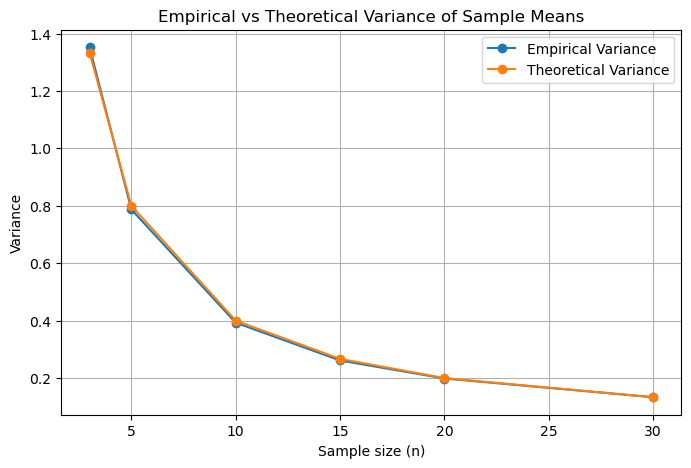

In [15]:
np.random.seed(0)
n_values = [3, 5, 10, 15, 20, 30]
sigma2 = 4
scale = 2
experiments = 10000

empirical_variance = []
theoretical_variance = []

for n in n_values:
    samples = np.random.exponential(scale=scale, size=(experiments, n))
    sample_means = samples.mean(axis=1)
    empirical_variance.append(np.var(sample_means))

    theo_var = sigma2 / n
    theoretical_variance.append(theo_var)

print("Theoretical Variance:")
for n, var in zip(n_values, theoretical_variance):
    print(f"n={n}: Variance = {var:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(n_values, empirical_variance, label='Empirical Variance', marker='o')
plt.plot(n_values, theoretical_variance, label='Theoretical Variance', marker='o')
plt.xlabel('Sample size (n)')
plt.ylabel('Variance')
plt.title('Empirical vs Theoretical Variance of Sample Means')
plt.legend()
plt.grid(True)
plt.show()

# Q7. Interactive Visualization of the Pareto Distribution

The **Pareto distribution** is a heavy-tailed probability distribution. It is characterized by a **shape parameter** $b$ and a **scale parameter**. For a Pareto distribution, the probability density function (PDF) is defined only for $x \ge \text{scale}$. The PDF is given by $f(x) = \frac{b \cdot \text{scale}^b}{x^{b+1}}$
### Task
Write a Python program to create an **interactive visualization of the Pareto distribution** using `scipy.stats` and `ipywidgets`.
1. Import the following libraries:
   - `numpy`
   - `matplotlib.pyplot`
   - `scipy.stats.pareto`
   - `ipywidgets.interact`

2. Define a function that plots the **Pareto probability density function (PDF)**.

3. Define the **x-axis range** as $x \in [\text{scale},\ \text{scale} + 10]$ using **400 evenly spaced points**.

4. Plot the Pareto PDF using matplotlib.

5. Use `ipywidgets.interact` to create interactive sliders that allow the user to change:

- the shape parameter `𝑏`
- the scale parameter `scale`

6. Use the following ranges for the sliders:
   `b`: from 1.5 to 10.0 with step 0.1
   `scale`: from 0.5 to 3.0 with step 0.1

Display the current parameter values in the plot title.


In [ ]:
def plot_pareto(b=2.0, scale=1.0):
    
    # x range from scale to scale + 10 with 400 points
    x = np.linspace(scale, scale + 10, 400)
    
    # Pareto PDF
    y = stats.pareto.pdf(x, b, scale=scale)
    
    # Plot
    plt.figure(figsize=(8,5))
    plt.plot(x, y, label="Pareto PDF")
    plt.xlabel("x")
    plt.ylabel("Density")
    plt.title(f"Pareto Distribution PDF (b={b}, scale={scale})")
    plt.grid(True)
    plt.legend()
    plt.show()

# Interactive sliders
widgets.interact(lambda b, scale: plot_pareto(b=b, scale=scale), b=(1.5, 10.0, 0.1), scale=(0.5, 3.0, 0.1));

interactive(children=(FloatSlider(value=5.7, description='b', max=10.0, min=1.5), FloatSlider(value=1.70000000…

# Q8. Statistical computations

Given **Virat Kohli's ODI scores** stored in the file `kohli.txt` (used in class), suppose he is going to play in an **ODI series of 3 matches**.

We would like to estimate the **maximum number of runs he might score in the series**.

Because the distribution of cricket scores is not known and the statistic of interest is the **maximum of 3 matches**, we will estimate this using **simulation (bootstrap sampling)**.

### Task

1. Load the scores from `kohli.txt`.

2. Simulate a **3-match ODI series** by randomly sampling **3 scores with replacement** from Kohli's historical scores.

3. Compute the **maximum score** in that simulated series.

4. Repeat this process **at least 10,000 times** (number of simulations).

5. Store the maximum score from each simulation.

6. Using the simulated maximum scores, estimate a **50% confidence interval** for the maximum runs he might score in a 3-match series. A 50% confidence interval corresponds to the **25th percentile and the 75th percentile** of the simulated maximum scores.

In [18]:
kohli_data = np.loadtxt('data/kohli.txt')
num_simulations = 100000
max_scores = []

for _ in range(num_simulations):
    series = np.random.choice(kohli_data, size=3, replace=True)
    max_score = np.max(series)
    max_scores.append(max_score)

max_scores = np.array(max_scores)

lower = np.percentile(max_scores, 25)
upper = np.percentile(max_scores, 75)

print(f"50% confidence interval for the maximum score in a 3-match series:")
print(f"Lower bound: {lower:.2f}")
print(f"Upper bound: {upper:.2f}")

50% confidence interval for the maximum score in a 3-match series:
Lower bound: 59.00
Upper bound: 115.00
